# Simulating iceberg "Juliette"

In [1]:
#Imports
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone

In [2]:
#Define additional functions
def calc_iceberg_size(iceberg_in1):
    '''Correct iceberg size not supplied with empirical relations before seeding iceberg.
    '''
    lengths = np.array(iceberg_in1['length'])
    if 'length' in iceberg_in1 and 'width' not in iceberg_in1:
        iceberg_in1['width'] = 0.7*lengths*np.exp(-0.00062*length)
    if 'length' in iceberg_in1 and np.logical_or('draft' not in iceberg_in1,'sail' not in iceberg_in1):
        rho_i, rho_w = 900,1027 #kg/m3
        height = np.array(0.4*lengths*np.exp(-0.00062*lengths))
        if np.logical_and('draft' not in iceberg_in1, 'sail' in iceberg_in1): print('Implement')
        elif np.logical_and('draft' not in iceberg_in1, 'sail' not in iceberg_in1): draft = height*(rho_i/rho_w)
        if np.logical_and('sail' not in iceberg_in1, 'draft' not in iceberg_in1): sail = height*(1-rho_i/rho_w) 
        elif np.logical_and('sail' not in iceberg_in1, 'draft' in iceberg_in1): print('Implement')
        iceberg_in1['draft'] = draft
        iceberg_in1['sail'] = sail
    return iceberg_in1

In [3]:
#Read and subset tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';') #ADAPT
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first() #Daily subset
ds_3day = ds_daily.isel(date=slice(0, None, 3)) #3-daily subset

In [4]:
#Define index of initial simulation time steps
idx = np.arange(ds_3day.lat.size) #here, 3-dayly throughout observed trajectory
print(idx)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [10]:
#Dictionary of available input data
env={'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
     'topaz4_ensemble':'https://thredds.met.no/thredds/dodsC/accibergt42/topaz4_be_mem010.ncml',#'https://thredds.met.no/thredds/catalog/accibergt42/catalog.html',
            'topaz5': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',
            'topaz5_ensemble': 'https://thredds.met.no/thredds/catalog/accibergt5/catalog.html',
            'topaz6': '',
            'glophyanfc': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator)
            'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
            'wind_glophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', #2007-2026
            'wind_glophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', #2024-2026
            'era5':'../input/era5_juliette.nc'} #Has to be downloaded

In [11]:
wvals = env['wind_glophyre'] #choose wind input
lons, lats, times = ds_3day.lon[idx],ds_3day.lat[idx],[t.values.astype(datetime) for t in ds_3day.time[idx]]

for input_l in [[ovals,wvals] for oname,ovals in env.items() if 'wind' not in oname]: #Loops thorugh the ocean input
#for input_l in [env['topaz4_ensemble'],env['wind_glophyre'],]:
    oname='topaz4_ensemble'
    #Information that are similar (or varied similarely) for every initialisation. 
    n=5 #number of icebergs released on every initialisation
    randspace=np.random.rand(n)
    iceberg = {'length':150+randspace*100,'width':80+randspace*10, 
            'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1}
    iceberg = calc_iceberg_size(iceberg) #this function adds missing iceberg sizes
    #dimensions = {'length':[150,200,250],'width':[80,85,90],'water_form_drag_coef':[0.25,0.6,0.9,1.5],'wind_form_drag_coef':[0.5,0.7,1.3,1.5]}#Initial conditions varied similarely for every position
    #simulation
    o=OpenBerg(loglevel=20,logfile='../results/out.log')
    o.set_config('drift:max_age_seconds', 3600*24*3) #Terminates simulations 3 days after their individual initialisation
    o.add_readers_from_list(input_l) 
    for lon, lat, time in zip(lons, lats, times): #Loops through initialisations of time-positions
        o.seed_elements(lon=lon, lat=lat, time=time, number=n, radius=0, **iceberg)
    oi = o.run(duration=timedelta(days=int(idx.size*3)), #duration from first initialisation to last termination
               outfile='../results/juliette_%s.nc'%oname)
    oi

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 39.01it/s]
INFO - 2026-05-11T14:51:13Z - Selected dataset version: "202211"
INFO - 2026-05-11T14:51:13Z - Selected dataset part: "default"
WARNING - 2026-05-11T14:51:13Z - The dataset cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H, version '202211', part 'default' is currently being updated. Data after 2025-12-21T00:00:00.000Z may not be up to date.


(<GeoAxes: title={'center': 'OpenDrift - OpenBerg\n2025-09-24 00:00 to 2025-12-05 00:00 UTC (1729 steps)'}>,
 <Figure size 916.071x1100 with 1 Axes>)

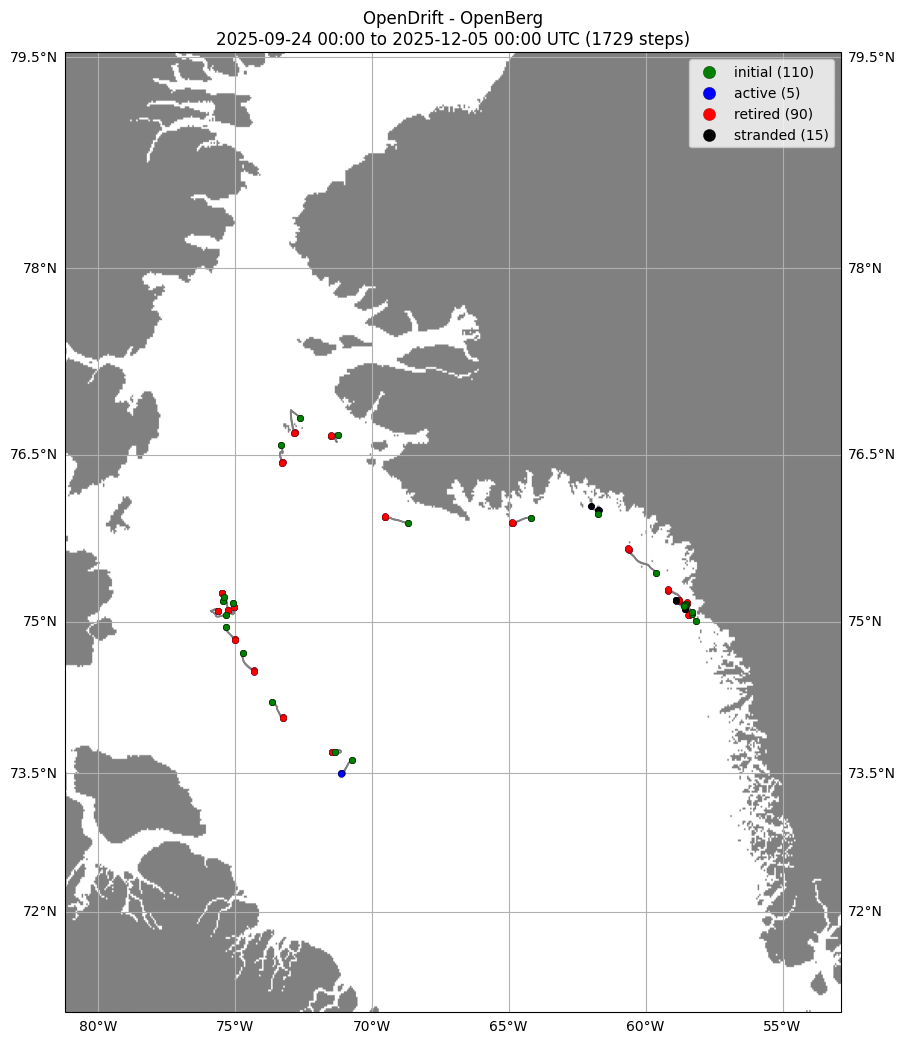

In [13]:
o.plot(fast=True,filename='../results/juliette_map.png')

In [ ]:
#o.plot_property('length')#,filename='../results/juliette_topaz4.png')